# Chapter 2 

# Chapter 2 Fully connected networks

## Neural networks - building a linear regression model and training loop

In [74]:
# Example of a model function and loss calculation

def F(X, y, f, theta):
    total_loss = 0
    for i in range (N):
        total_loss += loss(f(X[i,:], theta), y[i])
    return total_loss

In [1]:
# Import dependencies
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from idlmam import *

/home/efrain/Documents/Training-AI-ML-DL/Inside_Deep_Learning/idlmam.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


### Defining a Simple training model

In [2]:
# Simple training loop model

def train_simple_network(model, loss_func, training_loader, epochs=100, device="cpu"):
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

    model.to(device)

    for epoch in tqdm(range(epochs), desc="Epoch"):
        model = model.train()
        running_loss = 0.0

        for inputs, labels in tqdm(training_loader, desc="Batch", leave=False):
            inputs = moveTo(inputs, device)
            labels = moveTo(labels,device)

            optimizer.zero_grad()

            y_hat = model(inputs)

            loss = loss_func(y_hat, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

### Defining a dataset and dataloader

<Axes: >

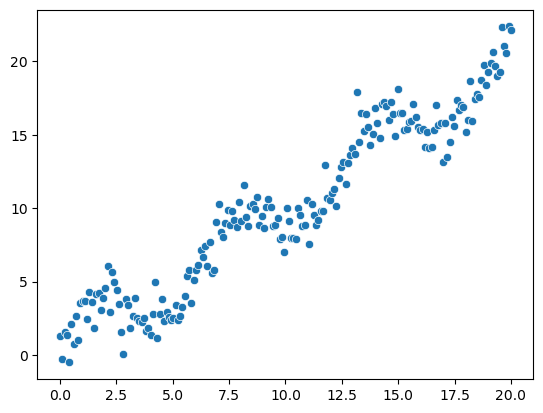

In [77]:
X = np.linspace(0, 20, 200)
y = X + np.sin(X)*2 + np.random.normal(size=X.shape)
sns.scatterplot(x=X, y=y)

In [3]:
# Data loader in pytorch

class Simple1DRegressionDataset(Dataset):
    def __init__(self, X, y):
        super(Simple1DRegressionDataset, self).__init__()
        self.X = X.reshape(-1,1)
        self.y = y.reshape(-1,1)

    def __getitem__(self, index):
        return torch.tensor(self.X[index,:], dtype=torch.float32), torch.tensor(self.y[index], dtype=torch.float32)
    
    def __len__(self):
        return self.X.shape[0]

In [79]:
training_loader = DataLoader(Simple1DRegressionDataset(X, y), shuffle=True)

### 

### Defining the model and loss function

Linear model in pytorch:
 - nn.Linear(d, C)

Loss functions in pytorch:
 - torch.nn.L1Loss = absolute loss |y - y_hat|
 - torch.nn.MSELoss = mean squared error loss (y - y_hat)**2

### Training a linear regression model on the data

In [ ]:
in_features = 1
out_features = 1
model = nn.Linear(in_features, out_features) # initial state
loss_function = nn.MSELoss()
device = torch.device("cpu")
train_simple_network(model, loss_function, training_loader, epochs=500, device=device)

<Axes: >

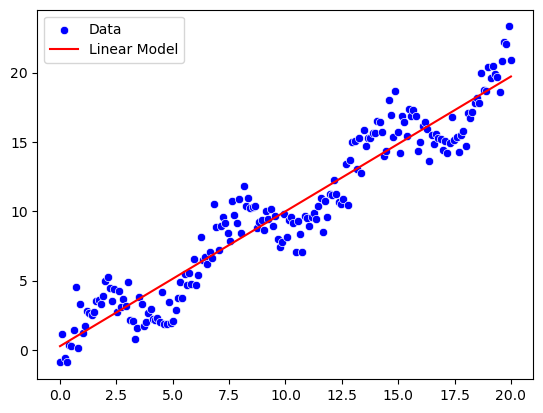

In [ ]:
with torch.no_grad():
    Y_pred = model(torch.tensor(X.reshape(-1,1), device=device, dtype=torch.float32)).cpu().numpy()

sns.scatterplot(x=X, y=y, color='blue', label='Data')
sns.lineplot(x=X, y=Y_pred.ravel(), color='red', label='Linear Model')

### Building a neural network

In [ ]:
model = nn.Sequential(
    nn.Linear(1,10),
    nn.Tanh(),
    nn.Linear(10,1)
)

train_simple_network(model, loss_function, training_loader, epochs=1000, device=device)

with torch.no_grad():
    Y_pred = model(torch.tensor(X.reshape(-1,1), dtype=torch.float32)).cpu().numpy()

Epoch: 100%|██████████| 1000/1000 [01:36<00:00, 10.34it/s]


<Axes: >

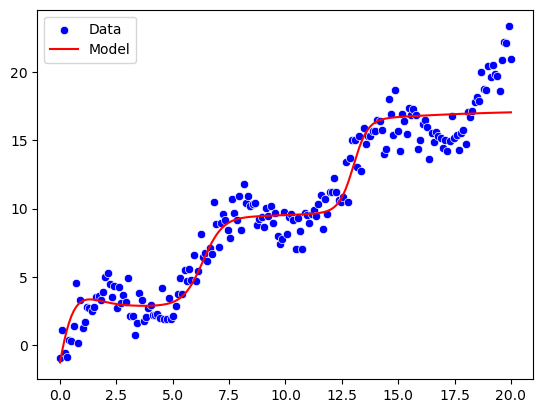

In [ ]:
# Plotting results
sns.scatterplot(x=X, y=y, color='blue', label='Data')
sns.lineplot(x=X, y=Y_pred.ravel(), color='red', label='Model')

### Classification problem

<Axes: >

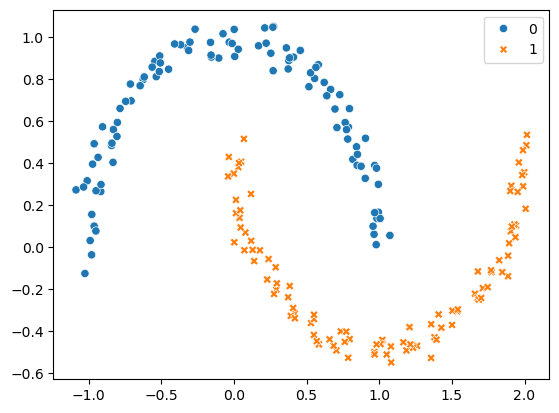

In [4]:
# Creating the dataset with scikit-learn

from sklearn.datasets import make_moons
X, y =  make_moons(n_samples=200, noise=0.05)
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, style=y)

In [ ]:
# Convert the data into a tensor with pytorch
classification_dataset = torch.utils.data.TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long))

# Add the training loader
training_loader2 = DataLoader(classification_dataset)

In [ ]:
# Define a linear classificatoin model
in_features2 = 2
out_features2 = 2
model2 = nn.Linear(in_features2, out_features2)
device2=torch.device('cpu')

The loss function needed for classification:
 - It is the combination of softmax (convert all results into probabilities that sums 1).
 - The cross-entropy loss that evaluates differences between 2 distributions.
 - Known as the logistic regression


In [5]:
# Adding the cross-entropy loss function
loss_func = nn.CrossEntropyLoss()

In [ ]:
train_simple_network(model2, loss_func, training_loader2, epochs=500, device=device2)

In [6]:
# Data visualization of 2D function with contour plot.
def visualize2DSoftmax(X, y, model, title=None):
    x_min = np.min(X[:,0])-0.5
    x_max = np.max(X[:,0])+0.5
    y_min = np.min(X[:,0])-0.5
    y_max = np.max(X[:,0])+0.5
    xv, yv = np.meshgrid(np.linspace(x_min, x_max, num=20), np.linspace(y_min, 1.5, num=20), indexing='ij')
    xy_v = np.hstack((xv.reshape(-1,1), yv.reshape(-1,1)))
    with torch.no_grad():
        logits = model(torch.tensor(xy_v, dtype=torch.float32))
        y_hat = F.softmax(logits, dim=1).numpy()

    cs = plt.contourf(xv, yv, y_hat[:,0].reshape(20,20), levels=np.linspace(0,1, num=20), cmap=plt.cm.RdYlBu)
    ax = plt.gca()
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, style=y, ax=ax)
    if title is not None:
        ax.set_title(title)

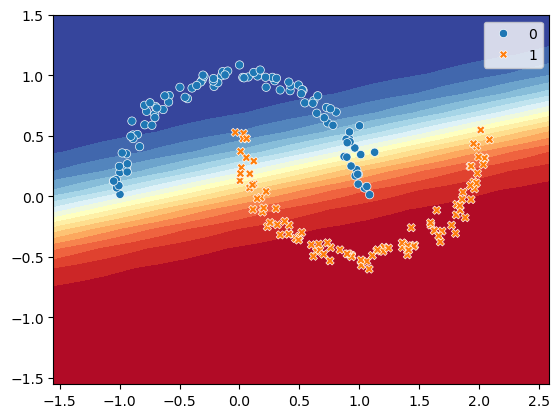

In [ ]:
visualize2DSoftmax(X, y, model2)

In [ ]:
# Better model with hidden layers
model3 = nn.Sequential(
    nn.Linear(2, 30),
    nn.Tanh(),
    nn.Linear(30, 30),
    nn.Tanh(),
    nn.Linear(30, 2)
)
train_simple_network(model3, loss_func, training_loader2, epochs=400)

Epoch: 100%|██████████| 400/400 [00:42<00:00,  9.47it/s]


In [ ]:
# Better model with hidden layers
model4 = nn.Sequential(
    nn.Linear(2, 30),
    nn.Tanh(),
    nn.Linear(30, 60),
    nn.Tanh(),
    nn.Linear(60, 30),
    nn.Tanh(),
    nn.Linear(30, 2)
)
train_simple_network(model4, loss_func, training_loader2, epochs=400)

Epoch: 100%|██████████| 400/400 [00:50<00:00,  7.97it/s]


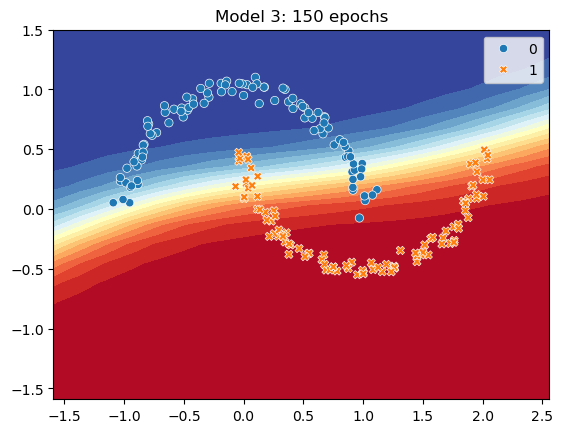

In [ ]:
visualize2DSoftmax(X, y, model3, title='Model 3: 150 epochs')

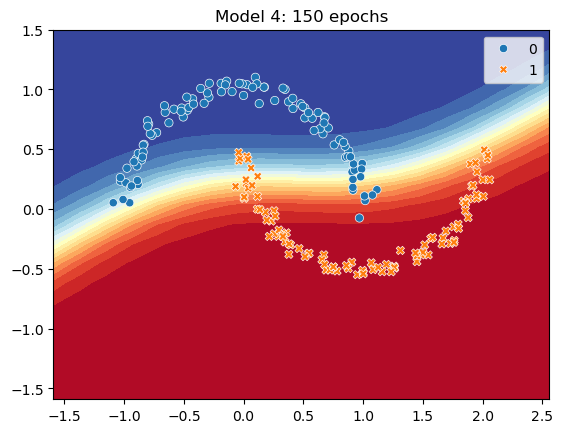

In [ ]:
visualize2DSoftmax(X, y, model4, title='Model 4: 150 epochs')

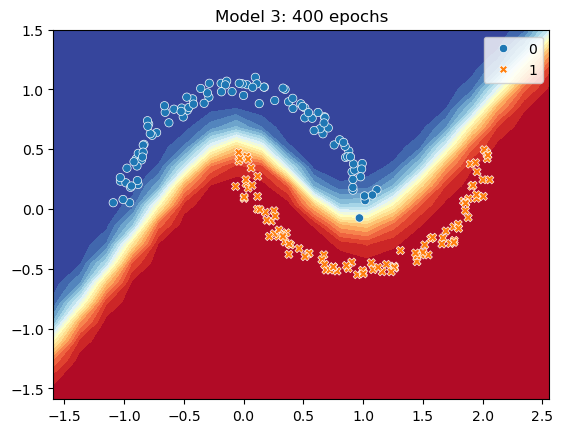

In [ ]:
visualize2DSoftmax(X, y, model3, title='Model 3: 400 epochs')

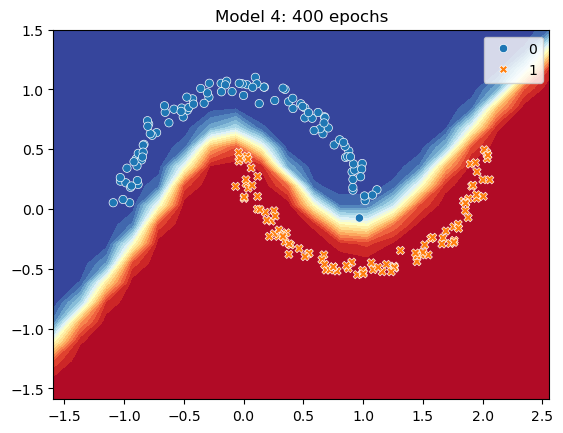

In [ ]:
visualize2DSoftmax(X, y, model4, title='Model 4: 400 epochs')

## A better model training function with metrics

In [27]:
# Better train model function

def train_simple_network_better(model, loss_func, train_loader, test_loader=None, score_funcs=None, 
                                epochs=300, device='cpu', checkpoint_file=None):
    
    """Train simple neural networks
    
    Keyword arguments:
    model -- the PyTorch model / "Module" to train
    loss_func -- the loss function that takes in batch in two arguments, the model outputs and the labels, and returns a score
    train_loader -- PyTorch DataLoader object that returns tuples of (input, label) pairs. 
    test_loader -- Optional PyTorch DataLoader to evaluate on after every epoch
    score_funcs -- A dictionary of scoring functions to use to evalue the performance of the model
    epochs -- the number of training epochs to perform
    device -- the compute lodation to perform training
    
    """
    to_track = ["epoch", "total time", "train loss"]
    if test_loader is not None:
        to_track.append("test loss")
    for eval_score in score_funcs:
        to_track.append("train " + eval_score )
        if test_loader is not None:
            to_track.append("test " + eval_score )
        
    total_train_time = 0 #How long have we spent in the training loop? 
    results = {}
    #Initialize every item with an empty list
    for item in to_track:
        results[item] = []
        
    #SGD is Stochastic Gradient Decent.
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
    #Place the model on the correct compute resource (CPU or GPU)
    model.to(device)

    for epoch in tqdm(range(epochs), desc="Epoch"):
        model = model.train()#Put our model in training mode
        
        total_train_time += run_epoch(model, optimizer, train_loader, loss_func, device, results, score_funcs, prefix="train", desc="Training")

        results["total time"].append( total_train_time )
        results["epoch"].append( epoch )
        
        if test_loader is not None:
            model = model.eval()
            with torch.no_grad():
                run_epoch(model, optimizer, test_loader, loss_func, device, results, score_funcs, prefix="test", desc="Testing")
                    
    if checkpoint_file is not None:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'results' : results
            }, checkpoint_file)
        
    return pd.DataFrame.from_dict(results)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

In [9]:
# Creating a large dataset using make_moons

X_train, y_train = make_moons(n_samples=8000, noise=0.4)
X_test, y_test = make_moons(n_samples=200, noise=0.4)

# Prepare data to pytorch as tensor
train_dataset =  TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                               torch.tensor(y_train, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                             torch.tensor(y_test, dtype=torch.long))

# Add data to loader
training_loader = DataLoader(train_dataset, shuffle=True)
testing_loader = DataLoader(test_dataset)

In [10]:
# Create a new model
model_b1 = nn.Sequential(
    nn.Linear(2, 30),
    nn.Tanh(),
    nn.Linear(30, 60),
    nn.Tanh(),
    nn.Linear(60, 180),
    nn.Tanh(),
    nn.Linear(180, 180),
    nn.Tanh(),
    nn.Linear(180, 60),
    nn.Tanh(),
    nn.Linear(60, 30),
    nn.Tanh(),
    nn.Linear(30, 2)
)

In [11]:
# Save results
results_pd = train_simple_network_better(model_b1, loss_func, training_loader, device='cpu',
                                         epochs=10, test_loader=testing_loader, checkpoint_file='model_b1.pt',
                                         score_funcs={'Acc': accuracy_score, 'F1': f1_score})

Epoch: 100%|██████████| 10/10 [01:34<00:00,  9.45s/it]


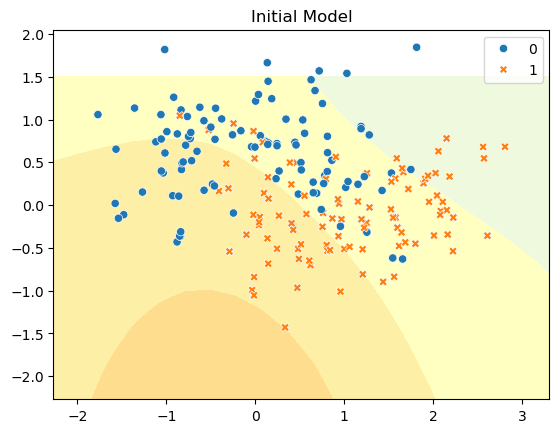

In [12]:
# Data visualization

model_vis = nn.Sequential(
    nn.Linear(2, 30),
    nn.Tanh(),
    nn.Linear(30, 30),
    nn.Tanh(),
    nn.Linear(30, 2)
)

visualize2DSoftmax(X_test, y_test, model_vis, title="Initial Model")
plt.show()


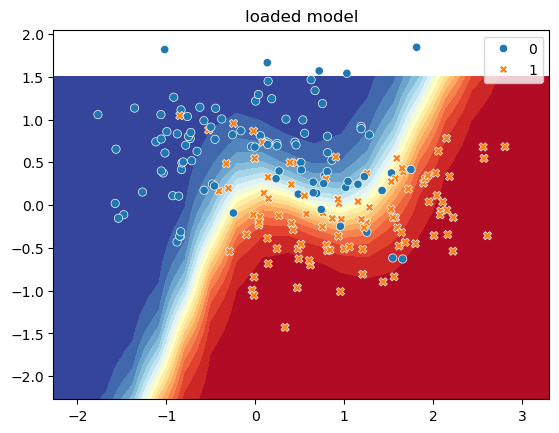

In [13]:
visualize2DSoftmax(X_test, y_test, model_b1, title="loaded model")
plt.show()

<Axes: xlabel='epoch', ylabel='train Acc'>

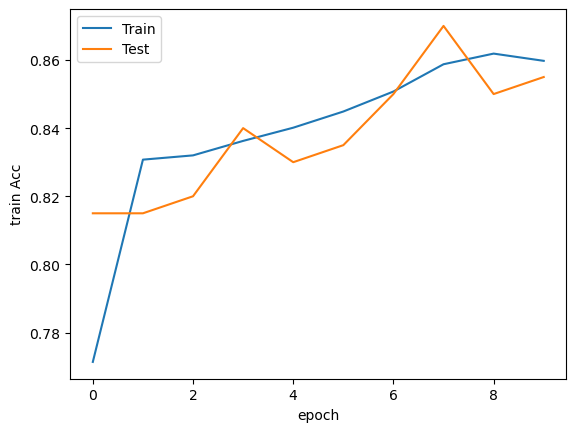

In [14]:
sns.lineplot(x='epoch', y='train Acc', data=results_pd, label='Train')
sns.lineplot(x='epoch', y='test Acc', data=results_pd, label="Test")

<Axes: xlabel='total time', ylabel='train F1'>

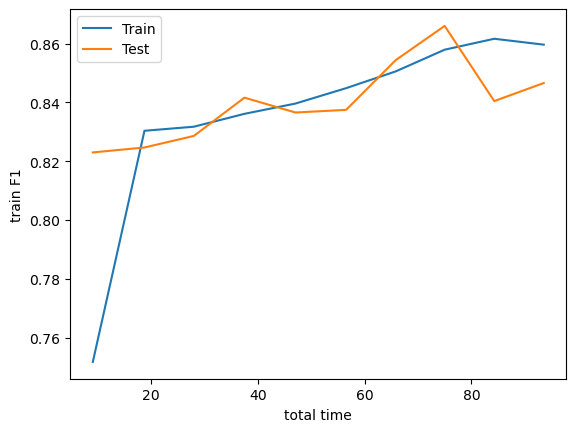

In [15]:
sns.lineplot(x='total time', y='train F1', data=results_pd, label='Train')
sns.lineplot(x='total time', y='test F1', data=results_pd, label="Test")

In [19]:
# Training in batches
training_loader_batches = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=True)
testing_loader_batches = DataLoader(test_dataset, batch_size=len(test_dataset))

In [18]:
# Describe the model
model_gb = nn.Sequential(
    nn.Linear(2, 30),
    nn.Tanh(),
    nn.Linear(30, 60),
    nn.Tanh(),
    nn.Linear(60, 180),
    nn.Tanh(),
    nn.Linear(180, 180),
    nn.Tanh(),
    nn.Linear(180, 60),
    nn.Tanh(),
    nn.Linear(60, 30),
    nn.Tanh(),
    nn.Linear(30, 2)
)

In [20]:
# train the new model
results_true_gd = train_simple_network_better(model_gb,
    loss_func,
    training_loader_batches,
    epochs=10,
    test_loader=testing_loader_batches,
    checkpoint_file='model_gb.pt',
    score_funcs={'Acc': accuracy_score, 'F1': f1_score}
)

Epoch: 100%|██████████| 10/10 [00:01<00:00,  7.44it/s]


<Axes: xlabel='total time', ylabel='test Acc'>

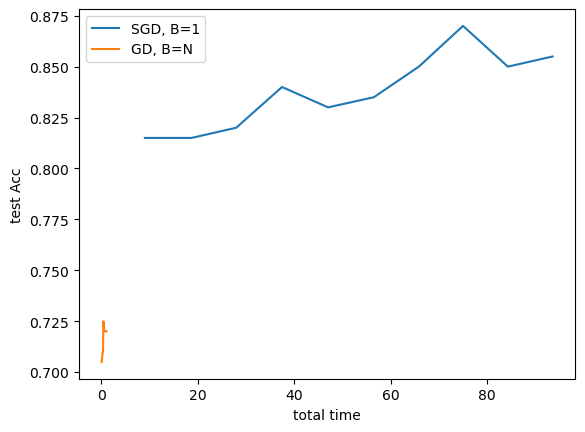

In [21]:
# Plotting results
sns.lineplot(x='total time', y='test Acc', data=results_pd, label='SGD, B=1')
sns.lineplot(x='total time', y='test Acc', data=results_true_gd, label='GD, B=N')

In [22]:
training_loader_batch_32 = DataLoader(train_dataset, batch_size=32, shuffle=True)
model_sgd = nn.Sequential(
    nn.Linear(2, 30),
    nn.Tanh(),
    nn.Linear(30, 60),
    nn.Tanh(),
    nn.Linear(60, 180),
    nn.Tanh(),
    nn.Linear(180, 180),
    nn.Tanh(),
    nn.Linear(180, 60),
    nn.Tanh(),
    nn.Linear(60, 30),
    nn.Tanh(),
    nn.Linear(30, 2)
)

In [23]:
results_batched = train_simple_network_better(model_sgd,
                                              loss_func,
                                              training_loader_batch_32,
                                              epochs=10,
                                              test_loader=testing_loader_batches,
                                              checkpoint_file='model_sgd_b.pt',
                                              score_funcs={'Acc': accuracy_score, 'F1': f1_score})


Epoch: 100%|██████████| 10/10 [00:03<00:00,  2.56it/s]


<Axes: xlabel='total time', ylabel='test Acc'>

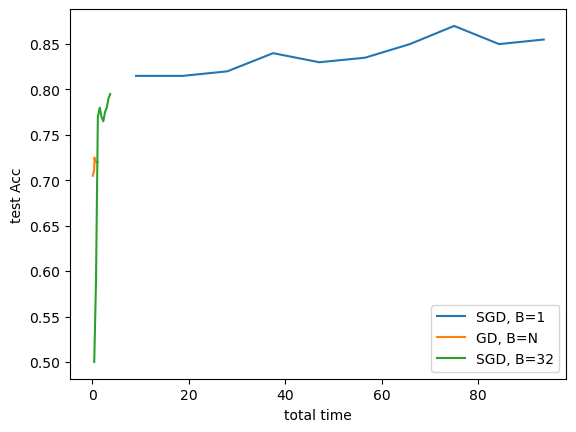

In [25]:
sns.lineplot(x='total time', y='test Acc', data=results_pd, label='SGD, B=1')
sns.lineplot(x='total time', y='test Acc', data=results_true_gd, label='GD, B=N')
sns.lineplot(x='total time', y='test Acc', data=results_batched, label='SGD, B=32')